# Pneumonia X-rays - Image Classification Task

### Imports and Loading

In [ ]:
import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.13.0


In [22]:
# Load the dataset into training, validation, and test sets
training_set = tf.keras.preprocessing.image_dataset_from_directory('pneumonia_images\\chest_xray\\train', color_mode='grayscale', image_size=(224, 224))
validation_set = tf.keras.preprocessing.image_dataset_from_directory('pneumonia_images\\chest_xray\\val', color_mode='grayscale', image_size=(224, 224))
test_set = tf.keras.preprocessing.image_dataset_from_directory('pneumonia_images\\chest_xray\\test', color_mode='grayscale', image_size=(224, 224))

# Check the class names
print("\nClass names:")
print(f"Training set: {training_set.class_names}")
print(f"Validation set: {validation_set.class_names}")
print(f"Testing set: {test_set.class_names}")

# Check the number of classes
print("\nNumber of classes:")
print(f"Training set: {len(training_set.class_names)}")
print(f"Validation set: {len(validation_set.class_names)}")
print(f"Testing set: {len(test_set.class_names)}")

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.

Class names:
Training set: ['NORMAL', 'PNEUMONIA']
Validation set: ['NORMAL', 'PNEUMONIA']
Testing set: ['NORMAL', 'PNEUMONIA']

Number of classes:
Training set: 2
Validation set: 2
Testing set: 2


### Data Preprocessing and Checks

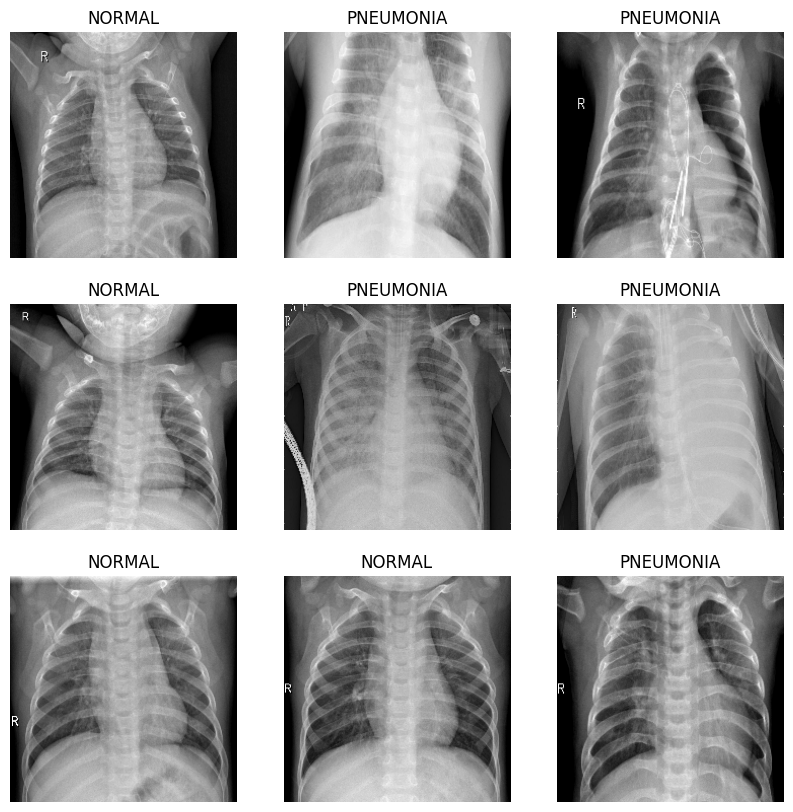

In [6]:
# Check first few images in the training set
plt.figure(figsize=(10, 10))
for images, labels in training_set.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"), cmap='gray')
        plt.title(training_set.class_names[labels[i]])
        plt.axis("off")
plt.show()

In [8]:
# Convert datasets to numpy arrays and corresponding labels

# arrays to hold the images and labels
# Note: The images are in grayscale, so they will have a shape of (224, 224, 1)
X_train, y_train = [], []
X_val, y_val = [], []
X_test, y_test = [], []

# Convert all datasets to numpy arrays
for batch in training_set:
    images, labels = batch
    X_train.append(images.numpy())
    y_train.append(labels.numpy())

for batch in validation_set:
    images, labels = batch
    X_val.append(images.numpy())
    y_val.append(labels.numpy())

for batch in test_set:
    images, labels = batch
    X_test.append(images.numpy())
    y_test.append(labels.numpy())

# Concatenate the lists into numpy arrays
X_train = np.concatenate(X_train, axis=0)
y_train = np.concatenate(y_train, axis=0)
X_val = np.concatenate(X_val, axis=0)
y_val = np.concatenate(y_val, axis=0)
X_test = np.concatenate(X_test, axis=0)
y_test = np.concatenate(y_test, axis=0)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5216, 224, 224, 1)
y_train shape: (5216,)
X_val shape: (16, 224, 224, 1)
y_val shape: (16,)
X_test shape: (624, 224, 224, 1)
y_test shape: (624,)


In [23]:
unique, counts = np.unique(y_train, return_counts=True)
print("\nTraining set class distribution:")
print(dict(zip(unique, counts)))
unique, counts = np.unique(y_val, return_counts=True)
print("\nValidation set class distribution:")
print(dict(zip(unique, counts)))
unique, counts = np.unique(y_test, return_counts=True)
print("\nTesting set class distribution:")
print(dict(zip(unique, counts)))


Training set class distribution:
{0: 1341, 1: 3875}

Validation set class distribution:
{0: 8, 1: 8}

Testing set class distribution:
{0: 234, 1: 390}


There seems to be class imbalance in the training set, we will need some strategies later on if we want to improve model performance.

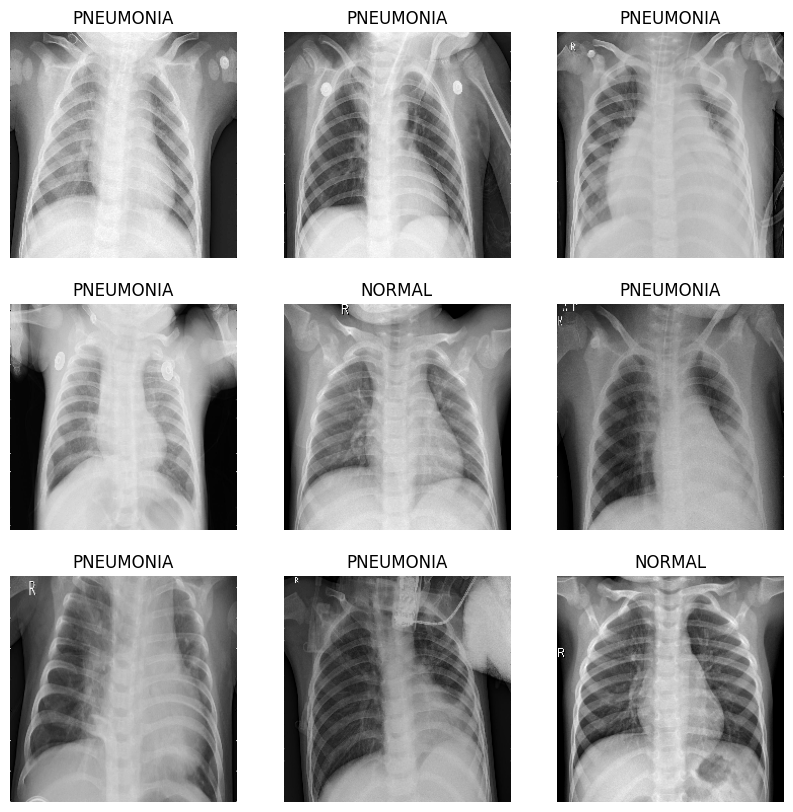

In [ ]:
# Check that the images are in grayscale and have the correct shape
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i].reshape(224, 224), cmap='gray')
    plt.title(training_set.class_names[y_train[i]])
    plt.axis("off")
plt.show()

Pixel value range: 0.0 to 255.0


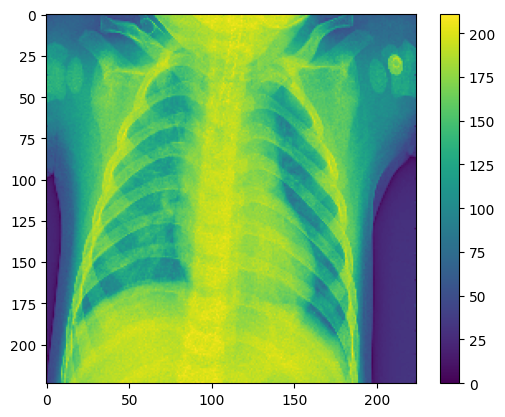

In [12]:
# Check the scale of the pixel values
print(f"Pixel value range: {X_train.min()} to {X_train.max()}")
plt.figure()
plt.imshow(X_train[0])
plt.colorbar()
plt.grid(False)
plt.show()

We can see that the pixel values of the images are in the range of 0-255. We will need to normalize these to between 0 and 1 for the CNN model by adding a normalization layer to the model when we build it.

### Building the Model - Dense Net

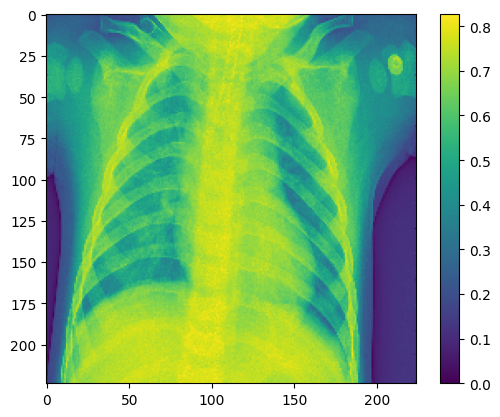

In [13]:
# Let's first define the normalization layer
normalization_layer = tf.keras.layers.Rescaling(1./255, input_shape=(224, 224, 1))

# Check the normalization layer
normalized_image = normalization_layer(X_train[0])
plt.figure()
plt.imshow(normalized_image)
plt.colorbar()
plt.grid(False)
plt.show()

First, let's try a single Dense layer with 128 neurons and a ReLU activation function. We will also add a Dropout layer to prevent overfitting. The output layer will have 1 neuron with a sigmoid activation function since this is a binary classification problem.

In [ ]:
dense_model = tf.keras.Sequential([
    normalization_layer,
    tf.keras.layers.Input(shape=(224, 224, 1)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

dense_model.compile(optimizer='adam',
                    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
                    metrics=['accuracy'])

# Train the model
dense_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/10


c:\Users\Malik\anaconda3\envs\tf_env\lib\site-packages\keras\src\backend.py:5805: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


163/163 [==============================] - 5s 31ms/step - loss: 0.9779 - accuracy: 0.7385 - val_loss: 0.7549 - val_accuracy: 0.5000
Epoch 2/10
163/163 [==============================] - 5s 31ms/step - loss: 0.3755 - accuracy: 0.7872 - val_loss: 0.6107 - val_accuracy: 0.8125
Epoch 3/10
163/163 [==============================] - 5s 31ms/step - loss: 0.3720 - accuracy: 0.8044 - val_loss: 0.7739 - val_accuracy: 0.6250
Epoch 4/10
163/163 [==============================] - 5s 31ms/step - loss: 0.3451 - accuracy: 0.8353 - val_loss: 0.4979 - val_accuracy: 0.7500
Epoch 5/10
163/163 [==============================] - 5s 32ms/step - loss: 0.3384 - accuracy: 0.8261 - val_loss: 0.7009 - val_accuracy: 0.6875
Epoch 6/10
163/163 [==============================] - 5s 28ms/step - loss: 0.3152 - accuracy: 0.8462 - val_loss: 0.4844 - val_accuracy: 0.8125
Epoch 7/10
163/163 [==============================] - 4s 27ms/step - loss: 0.3258 - accuracy: 0.8324 - val_loss: 0.8751 - val_accuracy: 0.5625
Epoch 8/10

In [37]:
# Evaluate the model on the test set
dense_test_loss, dense_test_acc = dense_model.evaluate(X_test, y_test, verbose=2)
print("\nTest accuracy:", dense_test_acc)
print("Test loss:", dense_test_loss)

20/20 - 0s - loss: 1.2857 - accuracy: 0.7099 - 199ms/epoch - 10ms/step

Test accuracy: 0.7099359035491943
Test loss: 1.2856919765472412


0.71 accuracy is not bad, but there is room for improvement.

### Building Another Model - Convolutional Neural Networks

In [26]:
cnn_model = tf.keras.Sequential([
    normalization_layer,
    tf.keras.layers.Input(shape=(224, 224, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam',
                    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
                    metrics=['accuracy'])

# Train the model
cnn_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/20
163/163 [==============================] - 68s 414ms/step - loss: 0.2786 - accuracy: 0.8888 - val_loss: 0.7901 - val_accuracy: 0.6875
Epoch 2/20
163/163 [==============================] - 67s 413ms/step - loss: 0.1215 - accuracy: 0.9559 - val_loss: 0.3965 - val_accuracy: 0.8125
Epoch 3/20
163/163 [==============================] - 70s 427ms/step - loss: 0.0978 - accuracy: 0.9638 - val_loss: 0.5984 - val_accuracy: 0.7500
Epoch 4/20
163/163 [==============================] - 69s 421ms/step - loss: 0.0928 - accuracy: 0.9674 - val_loss: 0.0549 - val_accuracy: 1.0000
Epoch 5/20
163/163 [==============================] - 68s 416ms/step - loss: 0.0680 - accuracy: 0.9764 - val_loss: 0.5476 - val_accuracy: 0.6875
Epoch 6/20
163/163 [==============================] - 67s 411ms/step - loss: 0.0621 - accuracy: 0.9814 - val_loss: 0.4059 - val_accuracy: 0.7500
Epoch 7/20
163/163 [==============================] - 68s 417ms/step - loss: 0.0435 - accuracy: 0.9816 - val_loss: 0.1412 - val_ac

In [38]:
# Evaluate the model on the test set
test_lossv1, test_accv1 = cnn_model.evaluate(X_test, y_test, verbose=2)
print("\nTest accuracy:", test_accv1)
print("Test loss:", test_lossv1)

20/20 - 2s - loss: 3.6881 - accuracy: 0.7308 - 2s/epoch - 119ms/step

Test accuracy: 0.7307692170143127
Test loss: 3.688096761703491


The model, while better than the Dense model, seems to be overfitting. With a training accuracy of 0.99 and a test set accuracy of 0.73, it is clear that the model is memorizing the training data rather than learning to generalize.

### Building Another Model - Combating Overfitting

To combat overfitting, we can using a less complex model and increasing dropout layers. We will also use data augmentation to increase the size of our training set and help the model generalize better.

Changing the filter sizes as well, since grayscale images have less color information, we can use smaller filter sizes to capture the features of the images better. In addition adjusting the learning rate to 0.0001 and using the Adam optimizer, we can help the model converge better.

In [30]:
cnn_model_v2 = tf.keras.models.Sequential([
    normalization_layer,
    tf.keras.layers.Input(shape=(224, 224, 1)),
        
    # Convolutional blocks
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),  # Added for stability
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.3),
        
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.3),
        
    # Classifier head
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

cnn_model_v2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
                    metrics=['accuracy'])

# Train the model
cnn_model_v2.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/20
163/163 [==============================] - 46s 275ms/step - loss: 0.4058 - accuracy: 0.9070 - val_loss: 1.5310 - val_accuracy: 0.5000
Epoch 2/20
163/163 [==============================] - 45s 275ms/step - loss: 0.1220 - accuracy: 0.9536 - val_loss: 2.9899 - val_accuracy: 0.5625
Epoch 3/20
163/163 [==============================] - 45s 274ms/step - loss: 0.0891 - accuracy: 0.9670 - val_loss: 2.3818 - val_accuracy: 0.5625
Epoch 4/20
163/163 [==============================] - 45s 273ms/step - loss: 0.0736 - accuracy: 0.9741 - val_loss: 0.6648 - val_accuracy: 0.7500
Epoch 5/20
163/163 [==============================] - 45s 274ms/step - loss: 0.0662 - accuracy: 0.9781 - val_loss: 0.4526 - val_accuracy: 0.8125
Epoch 6/20
163/163 [==============================] - 45s 274ms/step - loss: 0.0513 - accuracy: 0.9812 - val_loss: 0.2057 - val_accuracy: 0.9375
Epoch 7/20
163/163 [==============================] - 45s 278ms/step - loss: 0.0579 - accuracy: 0.9758 - val_loss: 0.3343 - val_ac

In [39]:
# Evaluate the model on the test set
test_lossv2, test_accv2 = cnn_model_v2.evaluate(X_test, y_test, verbose=2)
print("\nTest accuracy:", test_accv2)
print("Test loss:", test_lossv2)

20/20 - 1s - loss: 1.1201 - accuracy: 0.8221 - 1s/epoch - 64ms/step

Test accuracy: 0.8221153616905212
Test loss: 1.1200834512710571


82%! A step in the right direction, so it seems that the model is learning to generalize better. Let's try another model implementing data augmentation to see if we can improve the accuracy.

### Building Another Model - Data Augmentation

In [32]:
# Keeping the same architecture from before; adding data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
])

cnn_model_v3 = tf.keras.models.Sequential([
    normalization_layer,
    tf.keras.layers.Input(shape=(224, 224, 1)),

    # Data augmentation
    data_augmentation,
        
    # Convolutional blocks
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),  # Added for stability
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.3),
        
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.3),
        
    # Classifier head
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

cnn_model_v3.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
                    metrics=['accuracy'])

# Train the model
cnn_model_v3.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/20
163/163 [==============================] - 65s 390ms/step - loss: 0.5088 - accuracy: 0.8184 - val_loss: 9.3339 - val_accuracy: 0.5000
Epoch 2/20
163/163 [==============================] - 64s 392ms/step - loss: 0.2954 - accuracy: 0.8733 - val_loss: 15.2908 - val_accuracy: 0.5000
Epoch 3/20
163/163 [==============================] - 65s 399ms/step - loss: 0.2634 - accuracy: 0.8947 - val_loss: 8.2740 - val_accuracy: 0.5000
Epoch 4/20
163/163 [==============================] - 65s 399ms/step - loss: 0.2485 - accuracy: 0.8957 - val_loss: 4.0074 - val_accuracy: 0.5000
Epoch 5/20
163/163 [==============================] - 69s 422ms/step - loss: 0.2461 - accuracy: 0.8990 - val_loss: 2.2601 - val_accuracy: 0.6250
Epoch 6/20
163/163 [==============================] - 69s 425ms/step - loss: 0.2134 - accuracy: 0.9156 - val_loss: 0.6326 - val_accuracy: 0.7500
Epoch 7/20
163/163 [==============================] - 64s 395ms/step - loss: 0.2121 - accuracy: 0.9218 - val_loss: 0.9652 - val_a

In [40]:
# Evaluate the model on the test set
test_lossv3, test_accv3 = cnn_model_v3.evaluate(X_test, y_test, verbose=2)
print("\nTest accuracy:", test_accv3)
print("Test loss:", test_lossv3)

20/20 - 1s - loss: 0.4814 - accuracy: 0.8413 - 1s/epoch - 67ms/step

Test accuracy: 0.8413461446762085
Test loss: 0.48139092326164246


84% accuracy on the test set is slightly better than the previous model, so the data augmentation seems to be helping.

In [33]:
# Keeping the same architecture from before; adding data augmentation
cnn_model_v4 = tf.keras.models.Sequential([
    normalization_layer,
    tf.keras.layers.Input(shape=(224, 224, 1)),

    # Light data augmentation
    tf.keras.layers.RandomFlip("horizontal"),
        
    # Convolutional blocks
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),  # Added for stability
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.3),
        
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.3),
        
    # Classifier head
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

cnn_model_v4.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
                    metrics=['accuracy'])

# Train the model
cnn_model_v4.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/20
163/163 [==============================] - 65s 392ms/step - loss: 0.4783 - accuracy: 0.8395 - val_loss: 1.0316 - val_accuracy: 0.5625
Epoch 2/20
163/163 [==============================] - 64s 395ms/step - loss: 0.2101 - accuracy: 0.9314 - val_loss: 1.9187 - val_accuracy: 0.5000
Epoch 3/20
163/163 [==============================] - 64s 390ms/step - loss: 0.1761 - accuracy: 0.9446 - val_loss: 1.0848 - val_accuracy: 0.5000
Epoch 4/20
163/163 [==============================] - 63s 388ms/step - loss: 0.1712 - accuracy: 0.9469 - val_loss: 0.8834 - val_accuracy: 0.6250
Epoch 5/20
163/163 [==============================] - 63s 389ms/step - loss: 0.1591 - accuracy: 0.9561 - val_loss: 0.7374 - val_accuracy: 0.7500
Epoch 6/20
163/163 [==============================] - 63s 388ms/step - loss: 0.1492 - accuracy: 0.9636 - val_loss: 0.6290 - val_accuracy: 0.8125
Epoch 7/20
163/163 [==============================] - 63s 388ms/step - loss: 0.1389 - accuracy: 0.9632 - val_loss: 0.1886 - val_ac

In [42]:
# Evaluate the model on the test set
test_lossv4, test_accv4 = cnn_model_v4.evaluate(X_test, y_test, verbose=2)
print("\nTest accuracy:", test_accv4)
print("Test loss:", test_lossv4)

20/20 - 1s - loss: 1.4293 - accuracy: 0.7644 - 1s/epoch - 64ms/step

Test accuracy: 0.7644230723381042
Test loss: 1.4292882680892944


The minimal augmentation model seems to perform worse than the normal augmentation model as expected. The last model we will train will try to implement class weights to help deal with the class imbalance in the training set.

### One Last Model - Class Weights/Oversampling

In [36]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

print("\nClass weights:", class_weights)


Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


In [44]:
# Keeping the same architecture from before; adding class weights
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
])

cnn_model_v5 = tf.keras.models.Sequential([
    normalization_layer,
    tf.keras.layers.Input(shape=(224, 224, 1)),

    # Data augmentation
    data_augmentation,
        
    # Convolutional blocks
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),  # Added for stability
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.3),
        
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.3),
        
    # Classifier head
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

cnn_model_v5.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
                    metrics=['accuracy'])

# Train the model
cnn_model_v5.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val), class_weight=class_weights)

Epoch 1/20
163/163 [==============================] - 55s 329ms/step - loss: 0.7451 - accuracy: 0.7809 - val_loss: 2.0506 - val_accuracy: 0.5625
Epoch 2/20
163/163 [==============================] - 51s 313ms/step - loss: 0.3593 - accuracy: 0.8570 - val_loss: 4.1173 - val_accuracy: 0.5625
Epoch 3/20
163/163 [==============================] - 51s 315ms/step - loss: 0.3089 - accuracy: 0.8727 - val_loss: 2.2403 - val_accuracy: 0.5625
Epoch 4/20
163/163 [==============================] - 51s 310ms/step - loss: 0.2858 - accuracy: 0.8909 - val_loss: 0.8446 - val_accuracy: 0.8125
Epoch 5/20
163/163 [==============================] - 49s 299ms/step - loss: 0.2554 - accuracy: 0.8980 - val_loss: 0.6446 - val_accuracy: 0.7500
Epoch 6/20
163/163 [==============================] - 48s 297ms/step - loss: 0.2486 - accuracy: 0.9030 - val_loss: 0.6545 - val_accuracy: 0.7500
Epoch 7/20
163/163 [==============================] - 48s 294ms/step - loss: 0.2429 - accuracy: 0.9072 - val_loss: 0.5843 - val_ac

In [45]:
# Evaluate the model on the test set
test_lossv5, test_accv5 = cnn_model_v5.evaluate(X_test, y_test, verbose=2)
print("\nTest accuracy:", test_accv5)
print("Test loss:", test_lossv5)

20/20 - 1s - loss: 1.7273 - accuracy: 0.6154 - 1s/epoch - 53ms/step

Test accuracy: 0.6153846383094788
Test loss: 1.7273221015930176


It seems that the class weights are not helping the model learn any better. Both the accuracy and loss being worse than the v3 model. Combined with the low validation scores, the model is overfitting and memorizing the training data rather than learning to generalize. Since the class weights seem to be making the model worse, we will not use them in the final model.

### Summary and Data Visualizations

v3 seems to be the best model thus far, with an accuracy of 0.84 on the test set. Let's see the metrics for v3 to see exactly how well it's performing. As far as v3 is concerned, the metrics are:

20/20 [==============================] - 1s 56ms/step


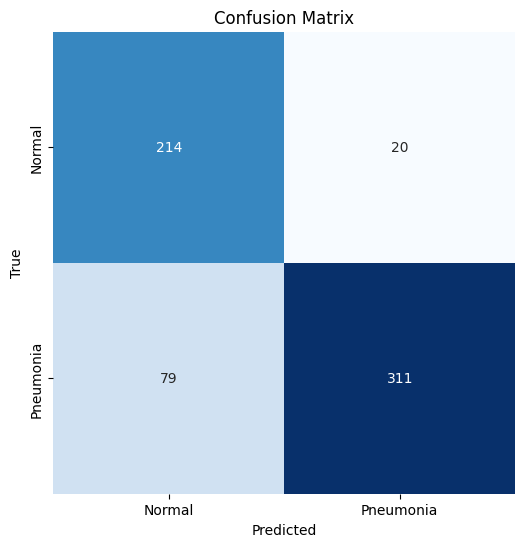


Classification Report:
              precision    recall  f1-score   support

      Normal       0.73      0.91      0.81       234
   Pneumonia       0.94      0.80      0.86       390

    accuracy                           0.84       624
   macro avg       0.83      0.86      0.84       624
weighted avg       0.86      0.84      0.84       624



In [48]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Get predictions
y_pred = cnn_model_v3.predict(X_test)
y_pred_classes = np.where(y_pred > 0.5, 1, 0).flatten()

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes, labels=[0, 1])
conf_matrix_df = pd.DataFrame(conf_matrix, index=["Normal", "Pneumonia"], columns=["Normal", "Pneumonia"])

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_df, annot=True, fmt='d', cmap='Blues', cbar=False, square=True)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Classification report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, target_names=["Normal", "Pneumonia"]))

In addition, lets see how the loss and accuacy of the models compare to each other.

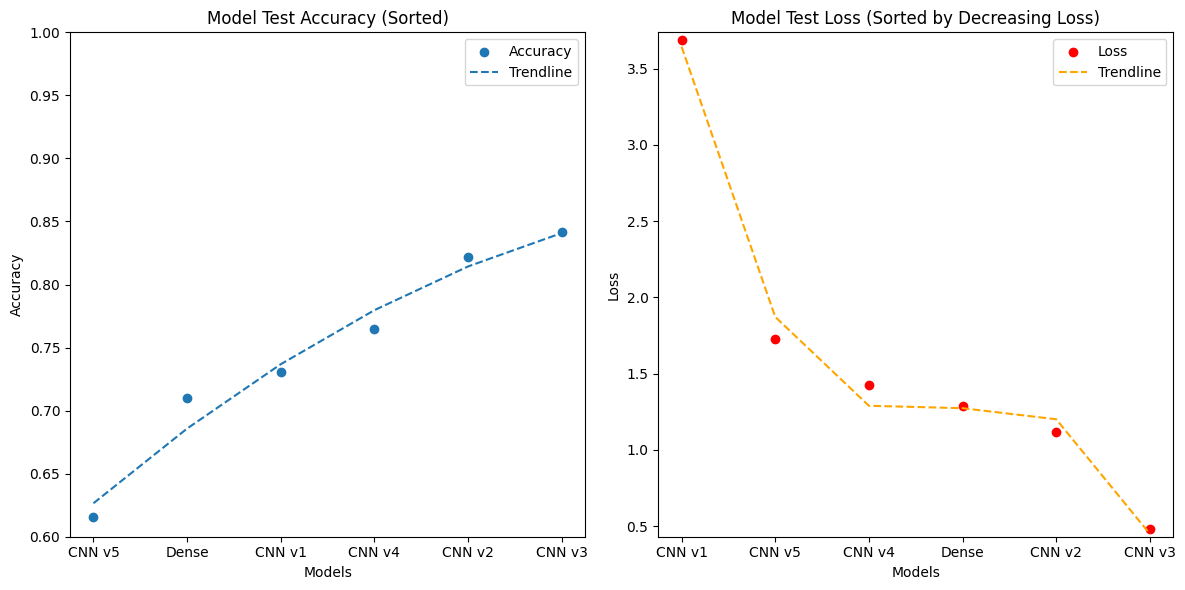

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Model performance data
models = ['Dense', 'CNN v1', 'CNN v2', 'CNN v3', 'CNN v4', 'CNN v5']
test_accuracies = [dense_test_acc, test_accv1, test_accv2, test_accv3, test_accv4, test_accv5]
test_losses = [dense_test_loss, test_lossv1, test_lossv2, test_lossv3, test_lossv4, test_lossv5]

# Sort by accuracy (increasing order)
sorted_indices_acc = np.argsort(test_accuracies)
models_sorted_acc = [models[i] for i in sorted_indices_acc]
test_accuracies_sorted = [test_accuracies[i] for i in sorted_indices_acc]
test_losses_sorted_acc = [test_losses[i] for i in sorted_indices_acc]

# Sort loss in decreasing order
sorted_indices_loss_desc = np.argsort(test_losses)[::-1]
models_sorted_loss_desc = [models[i] for i in sorted_indices_loss_desc]
test_losses_sorted_desc = [test_losses[i] for i in sorted_indices_loss_desc]

# Plot accuracy (sorted by accuracy)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(models_sorted_acc, test_accuracies_sorted, marker='o', label='Accuracy')
z = np.polyfit(range(len(models_sorted_acc)), test_accuracies_sorted, 2)
p = np.poly1d(z)
plt.plot(models_sorted_acc, p(range(len(models_sorted_acc))), linestyle='--', label='Trendline')
plt.title('Model Test Accuracy (Sorted)')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.ylim(0.6, 1.0)
plt.legend()

# Plot loss (sorted by decreasing loss)
plt.subplot(1, 2, 2)
plt.scatter(models_sorted_loss_desc, test_losses_sorted_desc, marker='o', color='red', label='Loss')
z_desc = np.polyfit(range(len(models_sorted_loss_desc)), test_losses_sorted_desc, 3)
p_desc = np.poly1d(z_desc)
plt.plot(models_sorted_loss_desc, p_desc(range(len(models_sorted_loss_desc))), linestyle='--', color='orange', label='Trendline')
plt.title('Model Test Loss (Sorted by Decreasing Loss)')
plt.xlabel('Models')
plt.ylabel('Loss')
plt.ylim(min(test_losses_sorted_desc) - 0.05, max(test_losses_sorted_desc) + 0.05)  # Dynamically adjust y-axis limits
plt.legend()

plt.tight_layout()
plt.show()